In [1]:
import pandas as pd
import numpy as np
from tqdm.auto import tqdm
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from TMFG_core import TMFG

/Users/simone/Library/Python/3.9/lib/python/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df_nmi = pd.read_csv("lob_similarity_nmi_rellag_lag150_bins250.csv")

In [4]:
df_nmi

,Unnamed: 0,ask_0_lag_0,ask_0_lag_1,ask_0_lag_2,ask_0_lag_3,ask_0_lag_4,ask_0_lag_5,ask_0_lag_6,ask_0_lag_7,ask_0_lag_8,...,bid_9_lag_141,bid_9_lag_142,bid_9_lag_143,bid_9_lag_144,bid_9_lag_145,bid_9_lag_146,bid_9_lag_147,bid_9_lag_148,bid_9_lag_149,bid_9_lag_150
0,ask_0_lag_0,1.000000,0.797162,0.698385,0.623363,0.568727,0.518152,0.479232,0.443053,0.414766,...,0.040247,0.040335,0.040224,0.040086,0.040039,0.040122,0.040027,0.039965,0.040012,0.039975
1,ask_0_lag_1,0.797162,1.000000,0.797162,0.698385,0.623363,0.568727,0.518152,0.479232,0.443053,...,0.040362,0.040247,0.040335,0.040224,0.040086,0.040039,0.040122,0.040027,0.039965,0.040012
2,ask_0_lag_2,0.698385,0.797162,1.000000,0.797162,0.698385,0.623363,0.568727,0.518152,0.479232,...,0.040520,0.040362,0.040247,0.040335,0.040224,0.040086,0.040039,0.040122,0.040027,0.039965
3,ask_0_lag_3,0.623363,0.698385,0.797162,1.000000,0.797162,0.698385,0.623363,0.568727,0.518152,...,0.040513,0.040520,0.040362,0.040247,0.040335,0.040224,0.040086,0.040039,0.040122,0.040027
4,ask_0_lag_4,0.568727,0.623363,0.698385,0.797162,1.000000,0.797162,0.698385,0.623363,0.568727,...,0.040571,0.040513,0.040520,0.040362,0.040247,0.040335,0.040224,0.040086,0.040039,0.040122
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3015,bid_9_lag_146,0.040122,0.040039,0.040086,0.040224,0.040335,0.040247,0.040362,0.040520,0.040513,...,0.369432,0.414225,0.459753,0.540777,0.642594,1.000000,0.642594,0.540777,0.459753,0.414225
3016,bid_9_lag_147,0.040027,0.040122,0.040039,0.040086,0.040224,0.040335,0.040247,0.040362,0.040520,...,0.343283,0.369432,0.414225,0.459753,0.540777,0.642594,1.000000,0.642594,0.540777,0.459753
3017,bid_9_lag_148,0.039965,0.040027,0.040122,0.040039,0.040086,0.040224,0.040335,0.040247,0.040362,...,0.314247,0.343283,0.369432,0.414225,0.459753,0.540777,0.642594,1.000000,0.642594,0.540777
3018,bid_9_lag_149,0.040012,0.039965,0.040027,0.040122,0.040039,0.040086,0.040224,0.040335,0.040247,...,0.296196,0.314247,0.343283,0.369432,0.414225,0.459753,0.540777,0.642594,1.000000,0.642594


In [5]:
df_nmi.describe()

,ask_0_lag_0,ask_0_lag_1,ask_0_lag_2,ask_0_lag_3,ask_0_lag_4,ask_0_lag_5,ask_0_lag_6,ask_0_lag_7,ask_0_lag_8,ask_0_lag_9,...,bid_9_lag_141,bid_9_lag_142,bid_9_lag_143,bid_9_lag_144,bid_9_lag_145,bid_9_lag_146,bid_9_lag_147,bid_9_lag_148,bid_9_lag_149,bid_9_lag_150
count,3020.000000,3020.000000,3020.000000,3020.000000,3020.000000,3020.000000,3020.000000,3020.000000,3020.000000,3020.000000,...,3020.000000,3020.000000,3020.000000,3020.000000,3020.000000,3020.000000,3020.000000,3020.000000,3020.000000,3020.000000
mean,0.049705,0.050003,0.050269,0.050508,0.050729,0.050931,0.051119,0.051294,0.051459,0.051614,...,0.054778,0.054670,0.054555,0.054433,0.054300,0.054157,0.053998,0.053822,0.053619,0.053379
std,0.040154,0.042425,0.044066,0.045313,0.046313,0.047116,0.047784,0.048341,0.048818,0.049223,...,0.039598,0.039363,0.039088,0.038769,0.038380,0.037916,0.037314,0.036545,0.035427,0.033741
min,0.031607,0.031641,0.031689,0.031689,0.031723,0.031885,0.031938,0.031938,0.031938,0.031938,...,0.038498,0.038498,0.038498,0.038498,0.038498,0.038498,0.038498,0.038498,0.038498,0.038498
25%,0.040378,0.040385,0.040392,0.040396,0.040402,0.040405,0.040415,0.040418,0.040426,0.040434,...,0.041869,0.041860,0.041849,0.041844,0.041833,0.041825,0.041815,0.041810,0.041804,0.041794
50%,0.041596,0.041604,0.041613,0.041624,0.041630,0.041639,0.041647,0.041654,0.041660,0.041669,...,0.043334,0.043295,0.043253,0.043178,0.043147,0.043116,0.043071,0.043046,0.043027,0.043012
75%,0.044432,0.044501,0.044551,0.044619,0.044696,0.044748,0.044823,0.044851,0.044864,0.044871,...,0.054290,0.054290,0.054290,0.054290,0.054290,0.054290,0.054290,0.054259,0.054233,0.054100
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [3]:
df_nmi_fixed = df_nmi.set_index('Unnamed: 0')

In [4]:
cols_lag0 = [c for c in df_nmi.columns if 'lag_0' in str(c)]

df_filtered = df_nmi_fixed.copy()

is_lag0_col = df_nmi_fixed.columns.isin(cols_lag0)
is_lag0_row = df_nmi_fixed.index.astype(str).str.contains('lag_0')

mask = np.outer(is_lag0_row, np.ones(len(is_lag0_col), dtype=bool)) | \
       np.outer(np.ones(len(is_lag0_row), dtype=bool), is_lag0_col)
df_filtered.values[~mask] = 0


In [5]:
df_filtered.describe()

,ask_0_lag_0,ask_0_lag_1,ask_0_lag_2,ask_0_lag_3,ask_0_lag_4,ask_0_lag_5,ask_0_lag_6,ask_0_lag_7,ask_0_lag_8,ask_0_lag_9,...,bid_9_lag_141,bid_9_lag_142,bid_9_lag_143,bid_9_lag_144,bid_9_lag_145,bid_9_lag_146,bid_9_lag_147,bid_9_lag_148,bid_9_lag_149,bid_9_lag_150
count,3020.000000,3020.000000,3020.000000,3020.000000,3020.000000,3020.000000,3020.000000,3020.000000,3020.000000,3020.000000,...,3020.000000,3020.000000,3020.000000,3020.000000,3020.000000,3020.000000,3020.000000,3020.000000,3020.000000,3020.000000
mean,0.049705,0.000585,0.000553,0.000527,0.000508,0.000490,0.000477,0.000464,0.000454,0.000444,...,0.000317,0.000317,0.000317,0.000317,0.000316,0.000316,0.000316,0.000316,0.000315,0.000315
std,0.040154,0.015163,0.013459,0.012181,0.011254,0.010412,0.009768,0.009184,0.008727,0.008284,...,0.003977,0.003975,0.003970,0.003966,0.003963,0.003957,0.003953,0.003950,0.003948,0.003947
min,0.031607,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.040378,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.041596,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.044432,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,1.000000,0.797162,0.698385,0.623363,0.568727,0.518152,0.479232,0.443053,0.414766,0.386436,...,0.069410,0.069486,0.068975,0.068907,0.068758,0.068639,0.068311,0.068341,0.068196,0.068066


In [6]:
tmfg = TMFG()
tmfg.fit(weights=df_filtered, output='unweighted_sparse_W_matrix')
cliques, separators, adj_matrix = tmfg.transform()

In [7]:
# Creazione del grafo NetworkX
G = nx.from_pandas_adjacency(pd.DataFrame(adj_matrix, index=df_filtered.index, columns=df_filtered.columns))

# Analisi del grafo

1. Market Influence (Redundancy-Filtered Hubs)

Unique Connection Leadership: Nonostante l'annullamento delle similarità ridondanti tra i lag, ask_1 e bid_1 restano i leader. Questo prova che la loro centralità non è un artefatto dovuto alla ripetizione temporale, ma una dominanza strutturale reale.

Effective Bridges: I nodi con alta Betweenness (ask_6, bid_4) agiscono come "canali di sbarramento": sono gli unici punti rimasti che collegano blocchi informativi diversi dopo che la ridondanza è stata eliminata.

Focus on Lag 0: La rete finale premia il tempo reale (lag_0), indicando che le relazioni cross-sectional sono più forti di qualsiasi legame predittivo residuo sopravvissuto al filtraggio.

2. Clique Composition (Temporal Chains)

Anti-Redundancy Effect: Il fatto che le clique abbiano solo 2 variabili diverse è il risultato diretto della tua regola. Eliminando le similarità tra lag (es. sim(A 
lag2
​	
 ,B 
lag1
​	
 )), hai costretto il sistema a collassare su catene verticali o coppie fisse.

Persistent Core: Il nucleo (bid_4 to bid_7) è la parte della matrice che ha resistito meglio alla rimozione della ridondanza. Rappresenta lo scheletro informativo più "originale" e meno ripetitivo dell'Order Book.

Structural Sparsity: La quasi totale assenza di clique con 3 o 4 variabili diverse conferma che, tolta la ridondanza, il mercato non è un blocco unico ma un insieme di processi a coppie altamente indipendenti.

3. Network Efficiency (Filtered Small-World)

Optimized Skeleton: Il TMFG ha costruito un grafo planare di 9.054 archi usando solo informazioni "nuove", avendo scartato quelle ridondanti. È una mappa dell'efficienza informativa pura.

High Local Cohesion: Il coefficiente di 0.83 dimostra che le variabili raggruppate (nonostante il taglio dei lag ridondanti) formano cluster estremamente solidi.

Small-World Robustness: Una distanza media di 5.65 in una rete così filtrata indica che il sistema Order Book è intrinsecamente connesso: anche eliminando i doppioni temporali, ogni nodo resta raggiungibile in pochissimi passaggi.

Top 10 Variabili più influenti (Hub):
             Degree Centrality  Betweenness
ask_2_lag_0           0.141438     0.202198
ask_1_lag_0           0.139450     0.099478
bid_5_lag_0           0.137463     0.452823
bid_1_lag_0           0.137463     0.099277
bid_2_lag_0           0.129182     0.201391
ask_8_lag_0           0.128851     0.105127
ask_6_lag_0           0.122557     0.479694
bid_6_lag_0           0.121232     0.068682
ask_5_lag_0           0.108976     0.280240
ask_7_lag_0           0.105995     0.170474
bid_4_lag_0           0.101689     0.286167
bid_7_lag_0           0.101358     0.217397
bid_8_lag_0           0.100696     0.096499
ask_3_lag_0           0.092746     0.225627
bid_3_lag_0           0.078503     0.194090
ask_4_lag_0           0.059954     0.245736
ask_9_lag_0           0.054323     0.001425
bid_0_lag_0           0.050679     0.001237
bid_9_lag_0           0.050679     0.001237
ask_0_lag_0           0.050679     0.001237


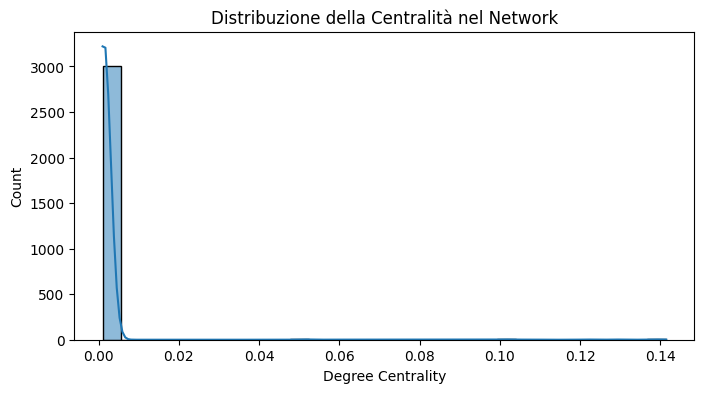

In [11]:
# Calcolo metriche
degree_cent = nx.degree_centrality(G)
betweenness = nx.betweenness_centrality(G)

# Creazione DataFrame per confronto
df_stats = pd.DataFrame({
    'Degree Centrality': pd.Series(degree_cent),
    'Betweenness': pd.Series(betweenness)
}).sort_values(by='Degree Centrality', ascending=False)

print("Top 10 Variabili più influenti (Hub):")
print(df_stats.head(20))

# Visualizzazione distribuzione gradi
plt.figure(figsize=(8, 4))
sns.histplot(df_stats['Degree Centrality'], bins=30, kde=True)
plt.title("Distribuzione della Centralità nel Network")
plt.show()

Nucleo del sistema (First 4-clique): ['bid_5_lag_0', 'bid_6_lag_0', 'bid_4_lag_0', 'bid_7_lag_0']


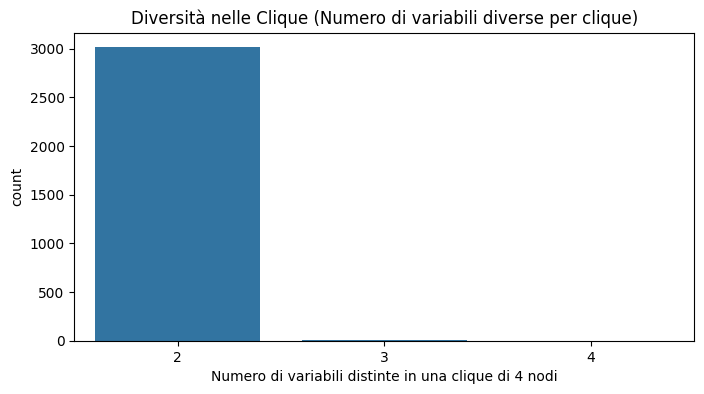

In [ ]:
# Analisi della prima clique (il nucleo del sistema)
core_nodes = [df_nmi_fixed.columns[i] for i in cliques[0]]
print(f"Nucleo del sistema (First 4-clique): {core_nodes}")

# Studio della composizione delle clique
def analyze_clique_composition(clique_indices):
    nodes = [df_nmi_fixed.columns[i] for i in clique_indices]
    base_names = [n.split('_lag')[0] for n in nodes]
    return len(set(base_names))

clique_diversity = [analyze_clique_composition(c) for c in cliques]
plt.figure(figsize=(8, 4))
sns.countplot(x=clique_diversity)
plt.title("Diversità nelle Clique (Numero di variabili diverse per clique)")
plt.xlabel("Numero di variabili distinte in una clique di 4 nodi")
plt.show()

In [ ]:
import networkx as nx
import numpy as np
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt

# --- 1. VERIFICA DELLA COERENZA TOPOLOGICA ---

n_nodi = len(G.nodes)
n_archi_attesi = 3 * n_nodi - 6
n_archi_reali = len(G.edges)

print(f"--- Validazione Topologica ---")
print(f"Nodi: {n_nodi} | Archi reali: {n_archi_reali} | Attesi: {n_archi_attesi}")
if n_archi_reali == n_archi_attesi:
    print("Stato: OK. Il grafo rispetta il vincolo di planarità TMFG.")

# --- 2. IDENTIFICAZIONE DEI "PONTI" (Bridges) ---

sep_flat = [node_idx for s in separators for node_idx in s]
sep_counts = Counter(sep_flat)

# Convertiamo gli indici in nomi di variabili
ponti_nomi = {df_nmi_fixed.columns[idx]: count for idx, count in sep_counts.items()}
df_ponti = pd.Series(ponti_nomi).sort_values(ascending=False)

print(f"\n--- Top 10 Nodi 'Ponte' (Frequenza nei Separatori) ---")
print(df_ponti.head(10))
#

# --- 3. ANALISI DEL MIXING (Cross-Variable Interaction) ---

clique_diversity = []
for c in cliques:
    nomi_nodi = [df_nmi_fixed.columns[i] for i in c]
    basi = set([n.split('_lag')[0] for n in nomi_nodi])
    clique_diversity.append(len(basi))

dist_diversita = Counter(clique_diversity)
print(f"\n--- Diversità delle Clique ---")
for n_var, count in dist_diversita.items():
    print(f"Clique con {n_var} variabili diverse: {count}")

# --- 4. ANALISI DELLA GERARCHIA (Distanza dal Core) ---
core_node_idx = cliques[0][0] 
core_node_name = df_nmi_fixed.columns[core_node_idx]

print(f"Calcolo distanze dal nodo core: {core_node_name}")

# Calcolo della distanza topologica (numero di salti minimi)
distanze = nx.single_source_shortest_path_length(G, core_node_name)
df_distanze = pd.Series(distanze).sort_values()

print(f"\n--- Nodi più vicini al CORE (Distanza Topologica) ---")
# Mostriamo i primi 10 nodi più vicini (escludendo i 4 nodi del core stesso)
print(df_distanze.iloc[4:14])

# --- 5. VALUTAZIONE SMALL-WORLD ---
# Un network TMFG è "Small-World" se ha un cammino medio breve e un clustering alto.

# Calcoliamo il percorso medio (Average Path Length)
path_length = nx.average_shortest_path_length(G)

# Calcoliamo il coefficiente di clustering medio
clustering_coeff = nx.average_clustering(G)

print(f"\n--- Metriche Small-World ---")
print(f"Percorso medio (Average Path Length): {path_length:.2f}")
print(f"Coefficiente di Clustering medio: {clustering_coeff:.2f}")

--- Validazione Topologica ---
Nodi: 3020 | Archi reali: 9054 | Attesi: 9054
Stato: OK. Il grafo rispetta il vincolo di planarità TMFG.

--- Top 10 Nodi 'Ponte' (Frequenza nei Separatori) ---
ask_2_lag_0    424
ask_1_lag_0    418
bid_5_lag_0    412
bid_1_lag_0    412
bid_2_lag_0    387
ask_8_lag_0    386
ask_6_lag_0    367
bid_6_lag_0    363
ask_5_lag_0    326
ask_7_lag_0    317
dtype: int64

--- Diversità delle Clique ---
Clique con 4 variabili diverse: 1
Clique con 3 variabili diverse: 4
Clique con 2 variabili diverse: 3012
Calcolo distanze dal nodo core: bid_5_lag_0

--- Nodi più vicini al CORE (Distanza Topologica) ---
bid_6_lag_16    1
bid_6_lag_15    1
bid_6_lag_14    1
bid_6_lag_13    1
bid_6_lag_12    1
bid_6_lag_11    1
bid_6_lag_10    1
bid_6_lag_20    1
bid_6_lag_9     1
bid_6_lag_7     1
dtype: int64

--- Metriche Small-World ---
Percorso medio (Average Path Length): 5.26
Coefficiente di Clustering medio: 0.83


# Creo visuale grafo

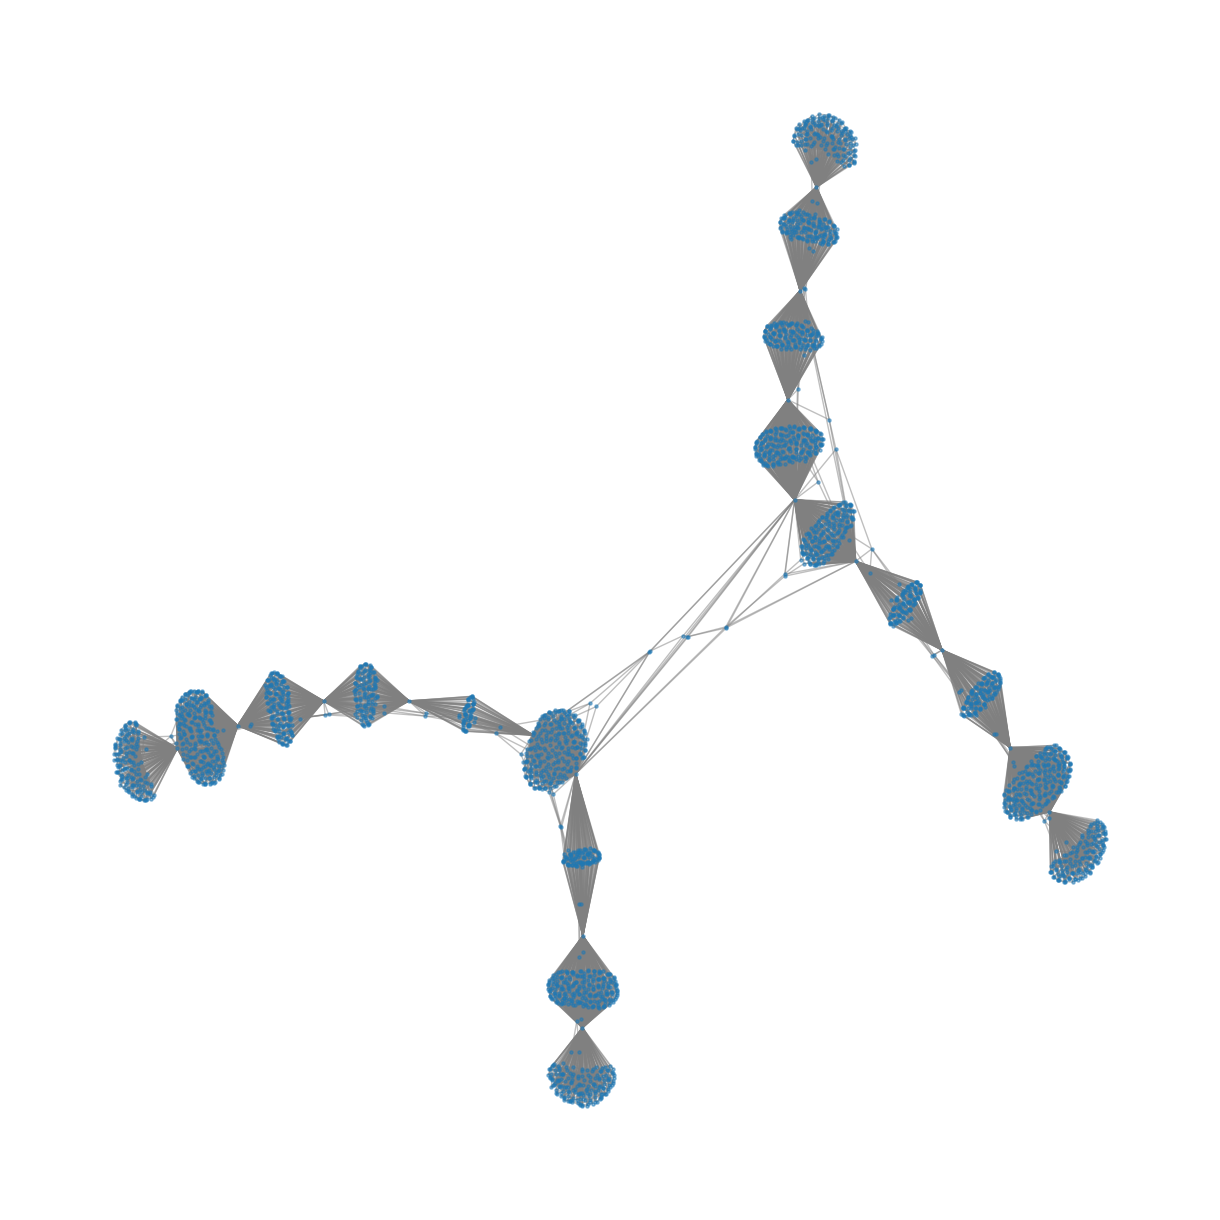

In [ ]:
plt.figure(figsize=(12, 12))
nx.draw(G, node_size=5, with_labels=False, edge_color='gray', alpha=0.5)
plt.show()

In [8]:
from pyvis.network import Network
import matplotlib.colors as mcolors
import random


net = Network(height="750px", width="100%", bgcolor="#222222", font_color="white", select_menu=True)

basi = sorted(list(set([n.split('_lag')[0] for n in df_nmi_fixed.columns])))

color_palette = list(mcolors.TABLEAU_COLORS.values()) 
random.shuffle(color_palette)
color_map = {base: color_palette[i % len(color_palette)] for i, base in enumerate(basi)}

for node in G.nodes:
    base_name = node.split('_lag')[0]
    colore = color_map.get(base_name, "#ffffff")
    net.add_node(node, label=node, color=colore, title=f"Variabile: {base_name}")

for edge in G.edges:
    net.add_edge(edge[0], edge[1])

net.set_options("""
{
  "physics": {
    "barnesHut": {
      "gravity": -80000,
      "damping": 0.5
    },
    "minVelocity": 0.75,
    "stabilization": {
      "enabled": true,
      "iterations": 2000
    }
  },
  "interaction": {
    "dragNodes": true,
    "hideEdgesOnDrag": false,
    "hideNodesOnDrag": false
  }
}
""")

net.save_graph("tmfg_colorato.html")